In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Problem 1

In [2]:
data_path = 'p1_data.csv'
p1_df = pd.read_csv(data_path)

In [3]:
# determine velocites, thickness of the top layer, locate the vertical discontinuity
"""
======== V2
V1  |  V3
    |
"""

'\n======== V2\nV1  |  V3\n    |\n'

In [4]:
# use eq 3.21 pg 74
revers_dist = p1_df.dist_from_shot_m[::-1]
revers_dist

11    120
10    110
9     100
8      90
7      80
6      70
5      60
4      50
3      40
2      30
1      20
0      10
Name: dist_from_shot_m, dtype: int64

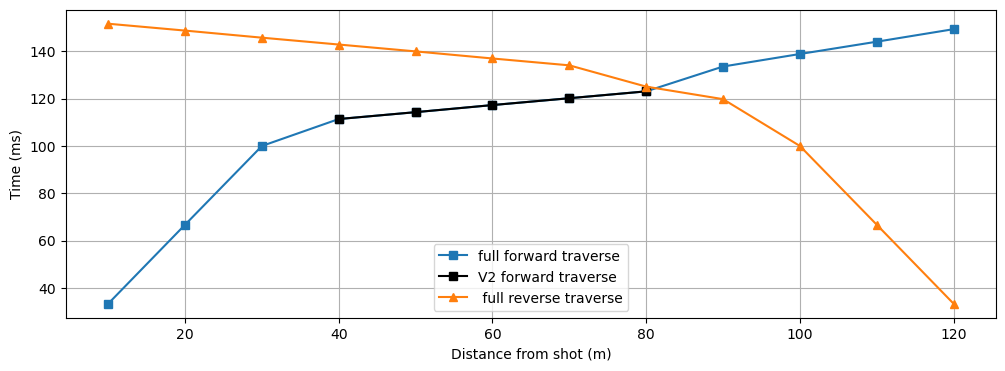

In [5]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(p1_df.dist_from_shot_m, p1_df.forward_traverse_ms, marker='s',label='full forward traverse')
ax.plot(p1_df.dist_from_shot_m[3:8], p1_df.forward_traverse_ms[3:8], marker='s',color='k',label='V2 forward traverse')
ax.plot(p1_df.dist_from_shot_m[::-1], p1_df.reverse_traverse_ms, marker='^',label=' full reverse traverse')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [6]:
# Forward velocities
v_2, t2_int = np.polyfit(p1_df.dist_from_shot_m[3:7], p1_df.forward_traverse_ms[3:7], 1)
# direct wave
v_1, t1_int = np.polyfit(p1_df.dist_from_shot_m[0:2], p1_df.forward_traverse_ms[0:2], 1)
# second layer
v_3, t3_int = np.polyfit(p1_df.dist_from_shot_m[8:11], p1_df.forward_traverse_ms[8:11], 1)


In [7]:
print(f"velocity of direct wave: {v_1*1000:.2f} m/s. Time intercept: {t2_int:.2f}.")
print(f"velocity of layer 1: {v_2*1000:.2f} m/s. Time-axis intercet: {t1_int}.")

print(f"velocity of layer 3: {v_3*1000:.2f} m/s. Time intercept: {t3_int:.2f}.")

velocity of direct wave: 3340.00 m/s. Time intercept: 99.63.
velocity of layer 1: 294.00 m/s. Time-axis intercet: -0.10000000000000392.
velocity of layer 3: 525.00 m/s. Time intercept: 86.37.


In [8]:
# thickness h1
h1 = (t2_int / 2) * (v_2 * v_1) / np.sqrt(np.square(v_1) - np.square(v_2))
print(f"thickness of horizontal top layer: {h1:.2f} m")

thickness of horizontal top layer: 14.70 m


# Problem 3

In [9]:
p3_path = 'p3_data.csv'
p3_df = pd.read_csv(p3_path)

In [10]:
# Forward velocities

# direct wave
v_direct, to_direct = np.polyfit(p3_df.distance_m[0:8], p3_df.fwd_traverse_ms[0:8], 1)

v_head, to_head = np.polyfit(p3_df.distance_m[9:11], p3_df.fwd_traverse_ms[9:11], 1)

# second layer
#vlyr_3, t3_o = np.polyfit(p1_df.dist_from_shot_m[8:11], p1_df.forward_traverse_ms[8:11], 1)

In [11]:
v_direct_sec = v_direct * 1000
v_head_sec = v_head * 1000
print(f"velocity of direct wave: {v_direct_sec:.2f} m/s. Time-axis intercet: {to_direct:.2f}.")
print(f"velocity of head wave: {v_head_sec:.2f} m/s. Time-axis intercet: {to_head:.2f}.")
#print(f"velocity of direct wave:{v_3*1000:.2f} m/s. Time intercept: {t3_int:.2f}.")

velocity of direct wave: 554.29 m/s. Time-axis intercet: 0.03.
velocity of head wave: 180.00 m/s. Time-axis intercet: 18.80.


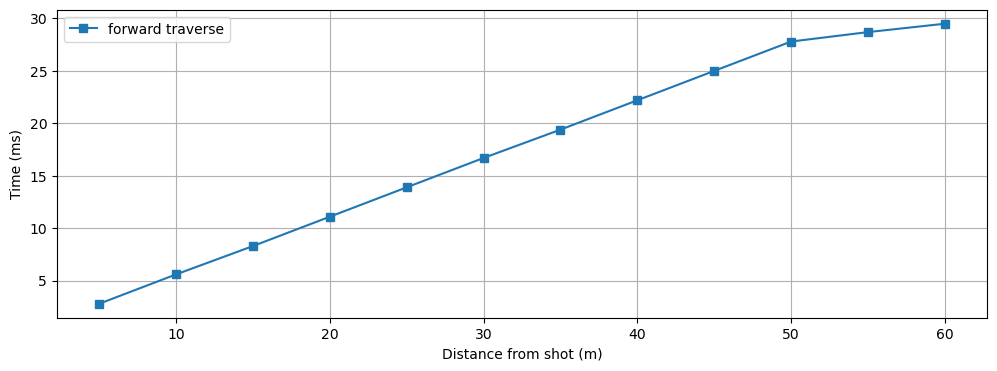

In [12]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(p3_df.distance_m, p3_df.fwd_traverse_ms, marker='s',label='forward traverse')
#ax.plot(p3_df.dist_from_shot_m[3:8], p3_df.forward_traverse_ms[3:8], marker='s',color='k',label='V2 forward traverse')
#ax.plot(p3_df.dist_from_shot_m[::-1], p3_df.reverse_traverse_ms, marker='^',label=' full reverse traverse')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [13]:
# two-layer problem
h1 = (to_head / 2) * ((v_head_sec * v_direct_sec) / np.sqrt(np.square(v_direct_sec) - np.square(v_head_sec)))
print(f'thickness with no well log data: {h1:.2f} m')

thickness with no well log data: 1788.96 m


In [14]:
v_low = 1200
h_1 = 3
# fix this
h2 = (to_head - (2 * h_1 * np.sqrt(np.square(v_direct_sec) - np.square(v_head_sec) ) / (v_head_sec * v_direct_sec)) * ((v_head_sec * v_low) / (2 * np.sqrt(np.square(v_low) - np.square(v_head_sec)))))
p_error = np.abs(h1 - h2) / h2
print(f'depth to bedrock with well log info: {h2:.2f} m')
print(f'percentage error: {p_error:.0%}')


depth to bedrock with well log info: 15.93 m
percentage error: 11130%


## Problem 4

In [15]:
p4_path = 'p4_data.csv'
p4_df = pd.read_csv(p4_path)

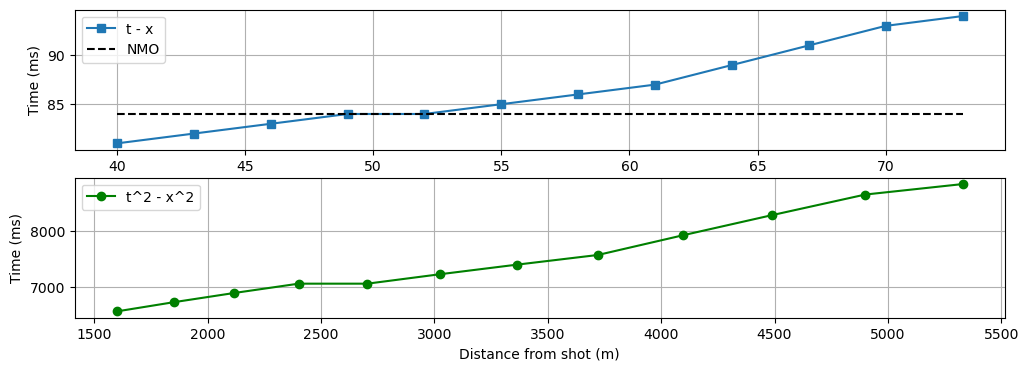

In [16]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,4))
ax1.plot(p4_df.x, p4_df.t, marker='s',label='t - x')
ax1.hlines(p4_df.t[3], p4_df.x.min(), p4_df.x.max(), colors='k',linestyles='--', label='NMO')
ax1.set_xlabel('Distance from shot (m)')
ax1.set_ylabel("Time (ms)")
ax1.legend(loc='best')
ax1.grid(True)

ax2.plot(np.square(p4_df.x), np.square(p4_df.t), marker='o',color='g',label='t^2 - x^2')
ax2.set_xlabel('Distance from shot (m)')
ax2.set_ylabel("Time (ms)")
ax2.legend(loc='best')
ax2.grid(True)

plt.show()

In [17]:
# reflection travel times squared
t_sqr = np.square(p4_df.t[4:13])
x_sqr = np.square(p4_df.x[4:13])

v_sqr, to_sqr = np.polyfit(x_sqr, t_sqr, 1)
print(f'slope (velocity):{v_sqr:.2f}, t-intercept: {to_sqr:.2f}')

slope (velocity):0.72, t-intercept: 5022.44


In [18]:
h1 = (np.sqrt(to_sqr)) * (np.sqrt(v_sqr)) / 2
print(f"thickness: {h1:.2f} m")

thickness: 30.05 m


## Problem 5

In [25]:
def compute_v(v_square):
    """ convert slope to velocity in m/ms"""
    return np.sqrt(1/v_square)

In [28]:
x = [418, 370, 322, 274, 276, 178, 130, 82, 34]
rflct_1 = [440, 435, 425, 422, 420, 415, 412, 410, 402]
v_1, to_1 = np.polyfit(np.square(x), np.square(rflct_1), 1)
print(f'RMS velocity of reflector 1: {compute_v(v_1):.2f} m/ms, to_1: {np.sqrt(to_1):.2f} ms')
rflct_2 = [492, 485, 477, 472, 469, 460, 455, 455, 450]
v_2, to_2 = np.polyfit(np.square(x), np.square(rflct_2), 1)
print(f'RMS velocity of reflector 2: {compute_v(v_2):.2f} m/ms, to_2: {np.sqrt(to_2):.2f} ms')
rflct_3 = [638, 632, 630, 625, 622, 621, 618, 618, 621]
v_3, to_3 = np.polyfit(np.square(x), np.square(rflct_3), 1)
print(f'RMS velocity of reflector 3: {compute_v(v_3):.2f} m/ms, to_3: {np.sqrt(to_3):.2f} ms')

RMS velocity of reflector 1: 2.47 m/ms, to_1: 406.52 ms
RMS velocity of reflector 2: 2.12 m/ms, to_2: 451.72 ms
RMS velocity of reflector 3: 2.71 m/ms, to_3: 617.44 ms


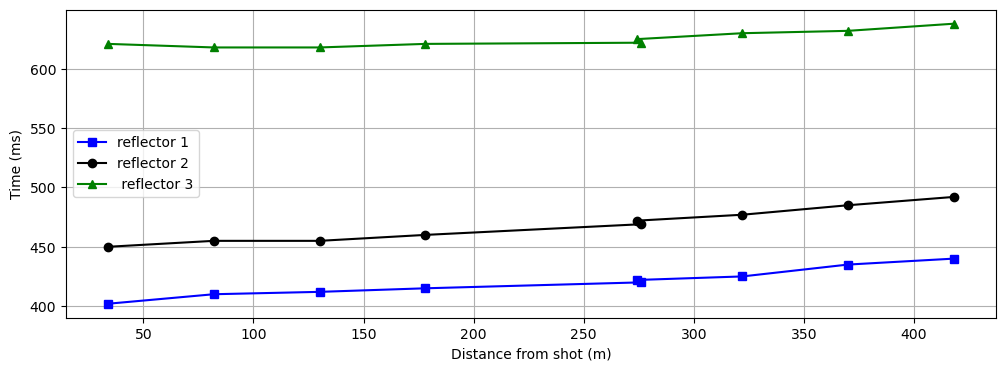

In [21]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(x, rflct_1, marker='s',color='b', label='reflector 1')
ax.plot(x, rflct_2, marker='o',color='k', label='reflector 2')
ax.plot(x, rflct_3, marker='^',color='g', label=' reflector 3')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
# interval velocity
def compute_v_interval(v_nrms, t_on, v_n1, t_on1):
    numerator = (v_nrms**2 *t_on) - (v_n1**2 * t_on1)
    demoninator = t_on - t_on1
    v_n = np.sqrt(numerator / demoninator)
    return v_n

In [ ]:
# reflector 2
compute_v_interval()